# Analyse following simultaneously to find any pattern (in progress):  
1. Find synchronisation core

#### Progress:
- 1st node in main cluster enters at 175 timestep and large number of nodes starts entering  main cluster at around 3299. This justifies that why there is rise in global order initially but not visible while plotting node community matrix
- Print only if node entries changes

- Plot number of nodes entering with timestep
- Compare above plots
- On comparing by superimposing, nothing meaningful can be inferred
- Found probability
- Arrange probability matrix in terms of node communities
- Algorithm finalised for finding important nodes (sir's algo)
- We have considered those cases also where no change occurs in nodes entering the main cluster
- Make final algorithm as a function
- Test it more !
- 

#### To do:

- Find top nodes i.e nodes which have highest probability to pull
- Also try arranging by 'total effectiveness' ie darkest horizontal lines at top and lightest at bottom.




In [1]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead 


from tes.analysis import AnalysisFunc

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm

import pandas as pd
import numpy as np
import networkx as nx
import seaborn as sns

from tes.DataUtils import DataUtils


#### Create objects


In [3]:
l=DataUtils()
reader=DataRead()
analyse=AnalysisFunc()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


# Plots of nodes entering into main cluster (all hidden)

#### Load data

In [4]:
df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')
df_itr_1 = reader.data_read_bz2('raw/FN/itr_400.bz2')
# df_loc = reader.data_read_bz2('raw/test/loc_test.bz2')


df_nc = reader.data_read_bz2('raw/FN/nc_200.bz2')
df_nc1=reader.data_read_bz2('raw/FN/nc_400.bz2')



In [5]:
df_nc1.head()

0    1    2    3    4    5    6    7    8    9    ...  416  417  418  \
1 0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
  1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
  2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
  3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
  4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

     419  420  421  422  423  424  425  
1 0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
  1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
  2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
  3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
  4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 426 columns]

#### Running analysis to get itration for analysis

In [ ]:
param=analyse.compute_param(df_itr,0.05)

#### Superimposing plots at node count = 100 to see if there really exists a pattern

## Concat node communities data

In [6]:
df_r=df_nc.reset_index(drop=True)
df_r1=df_nc1.reset_index(drop=True)





In [7]:
df_ncr=pd.concat([df_r,df_r1])

In [8]:
df_r1.shape

(695000, 426)

In [9]:
df_r.shape

(640000, 426)

In [10]:
df_ncr.shape

(1335000, 426)

In [11]:
df_ncr.shape[0]/5000

267.0

#### Using node count function to compute node entering main cluster at times when this count changes

In [13]:
i=0
f=5000
time_list=[]
node_count_list=[]
while f < df_r.shape[0]:
    l=analyse.node_count(df_r.iloc[i:f,:])
    time_list.append(l['timestep'])
    node_count_list.append(l['node_count'])
    i=f
    f+=5000

In [14]:
nc_df=pd.DataFrame(node_count_list).T
nc_df

,0,1,2,3,4,5,6,7,8,9,...,117,118,119,120,121,122,123,124,125,126
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,77.0,1.0,2.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,79.0,2.0,1.0,1.0,1.0,1.0
2,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,2.0,80.0,1.0,1.0,1.0,1.0,1.0
3,4.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,...,1.0,1.0,1.0,1.0,81.0,1.0,1.0,1.0,1.0,1.0
4,5.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,2.0,82.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
time_df=pd.DataFrame(time_list).T
time_df

,0,1,2,3,4,5,6,7,8,9,...,117,118,119,120,121,122,123,124,125,126
0,0.0,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1187.0,0.0,0.0,0.0,0.0,239.0,0.0,113.0,0.0,1195.0
1,4.0,36.0,53.0,31.0,2.0,8.0,5.0,48.0,15.0,12.0,...,1188.0,5.0,4.0,374.0,1.0,240.0,2.0,116.0,8.0,1199.0
2,5.0,42.0,74.0,54.0,9.0,9.0,11.0,74.0,24.0,19.0,...,1193.0,27.0,5.0,385.0,3.0,256.0,85.0,117.0,17.0,1208.0
3,13.0,46.0,79.0,57.0,11.0,11.0,16.0,84.0,58.0,20.0,...,1263.0,72.0,11.0,388.0,5.0,257.0,93.0,118.0,19.0,1255.0
4,25.0,50.0,81.0,76.0,12.0,170.0,19.0,86.0,68.0,26.0,...,1272.0,96.0,13.0,401.0,7.0,262.0,115.0,125.0,28.0,1375.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Plot node count entering at every timestep

In [ ]:
#plt.plot(time_df[0],nc_df[0],color='r')
plt.plot(time_df[1],nc_df[1],color='g')
plt.xlabel('Timesteps ')
# plt.xlabel('Timesteps at which node count or node number changes')
plt.ylabel('node count in main cluster ')
plt.title('Main cluster formation during transition')

We can also plot node count only above.

Text(0.5, 1.0, 'node count in. main cluster')

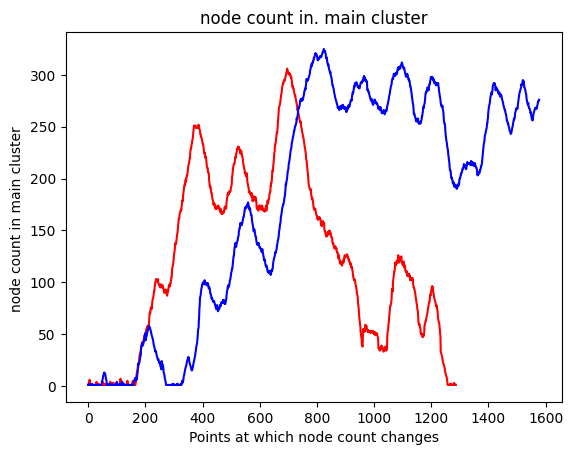

In [11]:

plt.plot(range(0,nc_df[0].shape[0]),nc_df[0],color='r')
plt.plot(range(0,nc_df[1].shape[0]),nc_df[1],color='b')
plt.xlabel('Points at which node count changes')
plt.ylabel('node count in main cluster ')
plt.title('node count in. main cluster')

#### Define the function for overlapping

In [9]:
def plot_nc_overlap(nc_df,name):
    df_check=nc_df.apply(lambda c: c>=100)
    
    set_point = 500
    c=0
    for i in range(0,df_check.shape[1]):
        for val in df_check[i]:
            
            c+=1
            if val == True:
                ts=c
                c=0
                break
        x=list(range(0,nc_df[i].shape[0]))
        
        if ts-1>set_point:
            # time_df[i].dropna(inplace=True)
            # nc_df[i].dropna(inplace=True)
            
            plt.plot(x,nc_df[i].shift(-(ts-set_point)),color=cm.Blues(0.8, 0.05), lw=1.5)
            plt.grid()
        else:
            # time_df[i].dropna(inplace=True)
            # nc_df[i].dropna(inplace=True)
            plt.plot(x,nc_df[i].shift(set_point-ts),color=cm.Blues(0.8, 0.05), lw=1.5)
            plt.grid()
        i+=1
    
    plt.xlabel("timestep")
    plt.ylabel("Node count")
    plt.title(name)
#plt.savefig('../../data/results/PIR_node_count.png')

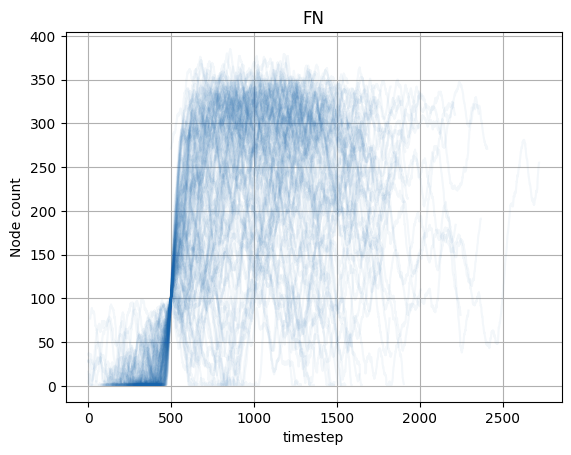

In [11]:
plot_nc_overlap(nc_df,'FN')

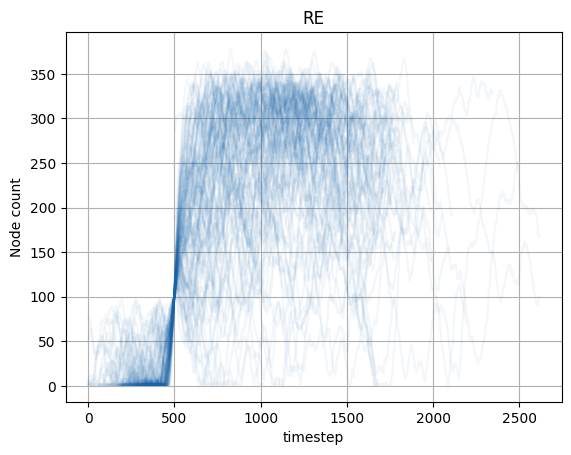

In [20]:
plot_nc_overlap(nc_df,'RE')

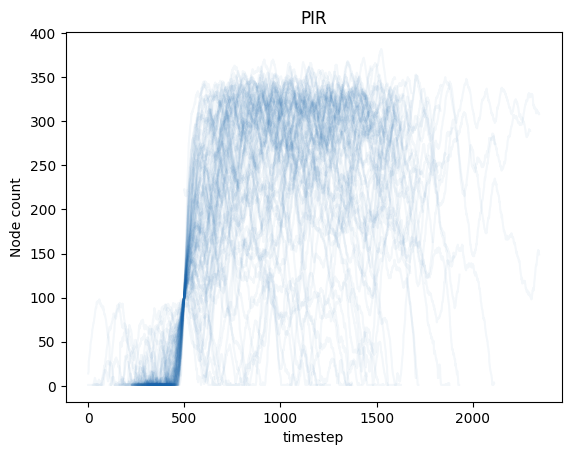

In [31]:
plot_nc_overlap(nc_df,'PIR')

From above, nothing meaningful after overlapping signals

In [16]:
#let's see if node list is calculated how
#df_nc.loc[2]

nl=analyse.node_count(df_nc.loc[2])
node_list=nl['node_list']


In [17]:
nl.keys()

dict_keys(['node_count', 'timestep', 'node_list'])

In [18]:
len(node_list)

1287

In [17]:
nl['node_list'][0:10]




[[71],
 [52],
 [50, 52, 71],
 [50, 52, 71, 263],
 [50, 52, 71, 263, 265],
 [50, 52, 71, 263, 265, 284],
 [52, 71, 263, 265, 284],
 [52, 265],
 [38],
 [57]]

# Plotting node list at every timestep that enters in the main cluster

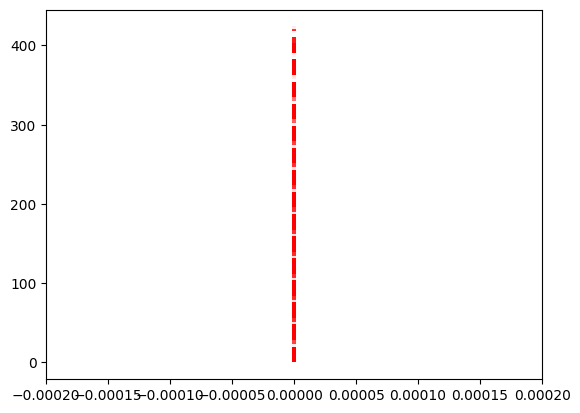

In [31]:
fig,ax = plt.subplots()
for i in nl['node_list']:
    x=[0]*len(i)
    y=i
    ax.plot(x,y,'r--',alpha=0.005,linewidth=3)
    #ax.plot(x,y,'go',alpha=0.05)
    ax.set_xlim(-0.0002,0.0002)
    




# Algorithm to find probability of nodes pulling other nodes

#### Test case to check algorithm

In [7]:
# defining test case to check for algorithm
test_list=[[1],[1, 2], [1,4,3],[2,5],[1,2,3]]
print(test_list)


test_list=[[1],[1, 2], [1,4,3],[2,5],[1,2,3]]

[[1], [1, 2], [1, 4, 3], [2, 5], [1, 2, 3]]


#### Defining it as a function for calculating probability (this algo breaks somewhere)

In [10]:
def prob_matrix(node_list):
    # defining network nodes list
    network_nodes = list(range(1, 6)) #427
    comp_list=network_nodes
    
    # use node_count function to extract node lists
    # nl=analyse.node_count(df_nc.loc[2])
    # node_list=nl['node_list']
    num_matrix = np.zeros((5,5)) #426,426
    den_matrix = np.zeros((5,5))
    test_list=node_list
    
    for n in network_nodes:
        
        #comp_list=temp_nodes
        #print(temp_nodes)
        #print(len(temp_nodes))
        comp_list.remove(n)
            
        for m in comp_list:
            
            for id, case in enumerate(test_list):
                if n in case and m not in case:
                    if id+1 != len(test_list):
                        if n in test_list[id+1] and m in test_list[id+1]:
                            num_matrix[n-1, m-1]+=1
                            den_matrix[n-1,m-1]+=1
                        else:
                            den_matrix[n-1,m-1]+=1
                    else:
                        break
                else:
                    continue
    
        comp_list=list(range(1,6))#427
    
    
    prob_matrix=np.divide(num_matrix,den_matrix)
    # print(num_matrix)
    # print(den_matrix)
    # print(prob_matrix)
    # arranging prob matrix nodes in order of mb communities
   # comm=reader.get_communities()
    # desired_order = list(comm.index)
    # reordered_mat=prob_matrix[desired_order,:]
    # final_mat=reordered_mat[:,desired_order]
    return prob_matrix
    
    
                    
                
        
        
        


In [11]:
prob_matrix(test_list)


/tmp/ipykernel_551807/1628343308.py:38: RuntimeWarning: invalid value encountered in divide
  prob_matrix=np.divide(num_matrix,den_matrix)


array([[nan, 0.5, 0.5, 0.5, 0. ],
       [nan, nan, nan, nan, nan],
       [nan, 0. , nan, nan, 0. ],
       [nan, 0. , nan, nan, 0. ],
       [0. , nan, 0. , 0. , nan]])

## Averaging probability matrices for nc data of FN (for 200 iterations)


In [84]:
df_r=df_nc.reset_index(drop=True)

In [ ]:
i=0
f=5000
p_mat_stack=[]
while f < df_r.shape[0]:
    # finding node list for given nc data
    l=analyse.node_count(df_r.iloc[i:f,:])
    # calculating probability matrix for above node list
    p_mat = prob_matrix(l['node_list'])
    p_mat=list(p_mat)
    p_mat_stack.append(p_mat)
  
    
    i=f
    f+=5000


mat_stack=np.stack(p_mat_stack,axis=0)
mat_avg=np.nanmean(mat_stack,axis=0)
    
np.save("../../data/raw/prob_avg",mat_avg)

In [7]:
prob_avg_mat=np.load("../../data/raw/prob_avg.npy")
prob_avg_mat.shape

(426, 426)

/tmp/ipykernel_391468/4240745689.py:1: RuntimeWarning: divide by zero encountered in log
  ax=plt.imshow(np.log(prob_avg_mat),cmap='RdBu')


Text(0, 0.5, 'Puller nodes')

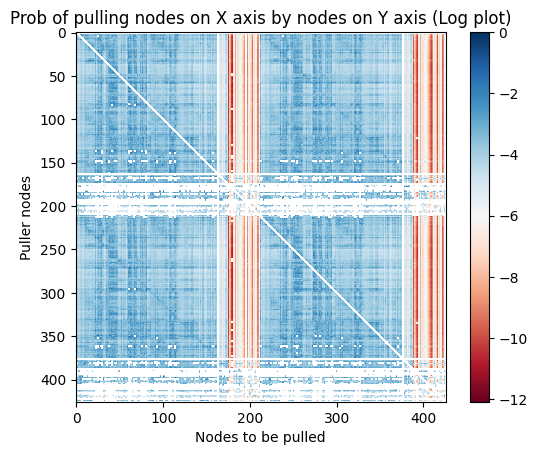

In [8]:
ax=plt.imshow(np.log(prob_avg_mat),cmap='RdBu')
plt.colorbar(ax)
plt.title('Prob of pulling nodes on X axis by nodes on Y axis (Log plot)')
plt.xlabel('Nodes to be pulled')
plt.ylabel('Puller nodes')

#### Arranging nodes in order of MB communities

/tmp/ipykernel_391468/3943947498.py:10: RuntimeWarning: divide by zero encountered in log
  axs=ax.imshow(np.log(final_mat),cmap='RdBu')


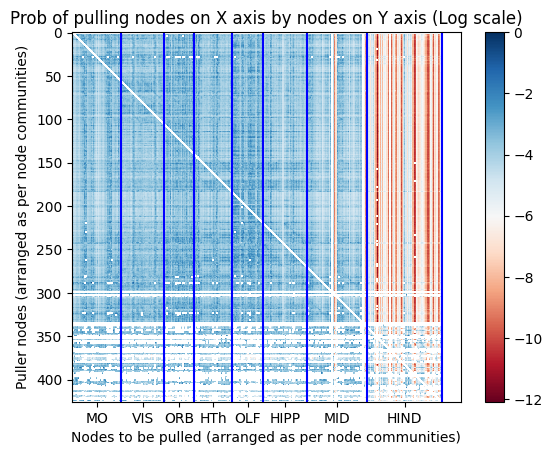

In [9]:
comm=reader.get_communities()
desired_order = comm['des_order']
reordered_mat=prob_avg_mat[desired_order,:]
final_mat=reordered_mat[:,desired_order]

# community divider lines 
com_div = np.cumsum(comm['comm_val'])

fig,ax=plt.subplots()
axs=ax.imshow(np.log(final_mat),cmap='RdBu')
fig.colorbar(axs)
for i in com_div:
    ax.axvline(i,color='b')
ax.set_xticks(com_div-comm['comm_val']/2)
ax.set_xticklabels(comm['name_seq'])
plt.title('Prob of pulling nodes on X axis by nodes on Y axis (Log scale)')
plt.xlabel('Nodes to be pulled (arranged as per node communities)')
plt.ylabel('Puller nodes (arranged as per node communities)')
plt.show()

# Trying to arrange darkest lines on the top


/tmp/ipykernel_106021/1657740091.py:9: RuntimeWarning: divide by zero encountered in log
  log_mat = np.log(final_mat)


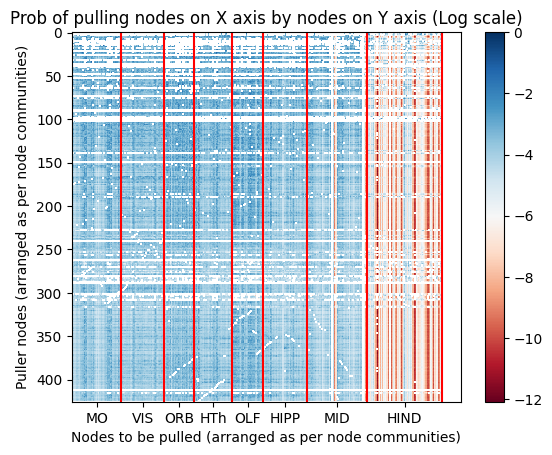

In [41]:
comm=reader.get_communities()
desired_order = comm['des_order']
reordered_mat=prob_avg_mat[desired_order,:]
final_mat=reordered_mat[:,desired_order]

# defining list to store count values
count=[]
# converting matrix to log matrix
log_mat = np.log(final_mat)
for i in range(0,final_mat.shape[0]):
    count_row=np.sum((log_mat[i,:]<=0) & (log_mat[i,:]>=-2))
    count.append(count_row)

# argsort count 
count=np.array(count)
ind=count.argsort()
# desired order of rows from darkest rows to lightest rows
des_order=ind[::-1]

final_mat=log_mat[des_order,:]

# community divider lines 
com_div = np.cumsum(comm['comm_val'])

fig,ax=plt.subplots()
axs=ax.imshow(final_mat,cmap='RdBu')
fig.colorbar(axs)
for i in com_div:
    ax.axvline(i,color='r')
ax.set_xticks(com_div-comm['comm_val']/2)
ax.set_xticklabels(comm['name_seq'])
plt.title('Prob of pulling nodes on X axis by nodes on Y axis (Log scale)')
plt.xlabel('Nodes to be pulled (arranged as per node communities)')
plt.ylabel('Puller nodes (arranged as per node communities)')
plt.show()

In [44]:
count[ind] 




array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [45]:
ind


array([425, 146, 147, 306, 149, 305, 152, 153, 154, 155, 304, 158, 159,
       299, 161, 297, 164, 165, 166, 167, 168, 169, 171, 173, 145, 174,
       144, 307, 112, 322, 320, 116, 117, 118, 119, 245, 316, 122, 123,
       315, 314, 129, 130, 310, 134, 135, 309, 308, 138, 139, 140, 143,
       175, 176, 294, 213, 214, 215, 216, 272, 270, 220, 221, 222, 261,
       224, 225, 227, 228, 229, 255, 254, 253, 234, 235, 249, 248, 246,
       273, 211, 209, 208, 291, 180, 287, 182, 285, 184, 185, 284, 187,
       188, 280, 111, 190, 279, 193, 195, 196, 198, 278, 202, 203, 205,
       206, 274, 191, 109, 319, 371, 387, 384, 382,  38,  41,  42,  43,
       378, 377, 376,  48,  49, 375, 374, 372,  53,  54, 329,  56,  58,
        59,  60,  62,  34,  63,  33, 391,   1, 421, 420, 419,   6, 418,
       417, 415,  10,  11,  13,  14, 414,  17, 412,  19,  20,  21, 408,
       403, 402, 397, 396, 389, 369, 244, 366, 353,  81, 100,  99,  83,
       339,  97,  85, 348,  96,  87,  88, 341, 346,  94, 344,  9

In [38]:
des_order[0:50]

array([395, 406, 357, 398, 413, 355, 363, 386, 349, 409, 364, 361, 351,
       385, 282, 281, 302, 350, 323, 416, 368, 411,  18, 288, 343, 401,
       410, 317, 324, 345, 379, 256, 407, 230, 250, 262,  26, 223, 219,
       263,  98, 325,   0, 289, 201, 394, 392, 422, 388, 404])

In [27]:
count=np.array(count)
ind=count.argsort()
des_order=ind[::-1]

array([406, 395, 357, 416, 288, 413, 411, 281, 256, 394, 323, 401, 407,
       350, 392, 351, 422, 363, 364, 355, 136, 131, 132, 133, 147, 134,
       135, 137, 143, 138, 146, 145, 139, 140, 141, 129, 144, 142, 130,
       425, 128, 127, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       148, 152, 149, 176, 178, 179, 180, 181, 182, 183, 184, 185, 186,
       187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199,
       200, 177, 175, 150, 174, 151, 102, 153, 154, 155, 156, 157, 158,
       159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171,
       172, 173, 103,  93, 101,  37,  27,  28,  29,  30,  31,  32,  33,
        34,  35,  36,  38,  25,  39,  40,  41,  42,  43,  44,  45,  46,
        47,  48,  26,  24, 100,  11,   1,   2,   3,   4,   5,   6,   7,
         8,   9,  10,  12,  23,  13,  14,  15,  16,  17,  18,  19,  20,
        21,  22,  49,  50,  51,  88,  78,  79,  80,  81,  82,  8

In [25]:
count

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [26]:
count[406]

3

In [21]:
np.unique(count)

array([0, 1, 2, 3])

AttributeError: module 'numpy' has no attribute 'count'

In [ ]:


peek_prob(prob_avg_mat)

In [60]:
#peek_prob(mat_avg)
mat_avg.shape
len(p_mat_stack)
#p_mat_stack

mat_stack.shape
mat_avg.shape


(426, 426)

In [39]:
# code for averaging arrays

a=np.array([[1,2],[3,4]])
b=np.array([[3,6],[3,6]])
r=[]
a=list(a)
b=list(b)
r.append(a)
r.append(b)
f_mat=np.stack(r,axis=0)
print(f_mat)
f_avg=np.nanmean(f_mat,axis=0)
print(f_avg)


[[[1 2]
  [3 4]]

 [[3 6]
  [3 6]]]
[[2. 4.]
 [3. 5.]]


In [38]:
f_avg=np.nanmean(f_mat,axis=0)
f_avg

array([[2., 4.],
       [3., 5.]])

In [34]:
f_avg.shape

(2, 2)

In [5]:
nl3=analyse.node_count(df_nc.loc[3])
l3=nl3['node_list']
p3=prob_matrix(l3)

[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[ 0.  0. 37. ... 64. 64. 64.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [23. 23.  0. ... 50. 50. 50.]
 ...
 [28. 28. 28. ...  0. 28. 28.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[       nan        nan 0.02702703 ... 0.         0.         0.        ]
 [       nan        nan        nan ...        nan        nan        nan]
 [0.         0.                nan ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ...        nan 0.         0.        ]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]]


/tmp/ipykernel_58307/3315779407.py:37: RuntimeWarning: invalid value encountered in divide
  prob_matrix=np.divide(num_matrix,den_matrix)


In [6]:
nl7=analyse.node_count(df_nc.loc[7])
l7=nl7['node_list']
p7=prob_matrix(l7)

[[0. 0. 3. ... 1. 5. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 1. 3. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [2. 0. 1. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[  0.   0. 198. ... 341. 182. 366.]
 [  0.   0.   0. ...   0.   0.   0.]
 [ 30.  18.   0. ... 174.  96. 198.]
 ...
 [  0.   0.   1. ...   0.   2.  25.]
 [ 79.   0. 161. ... 240.   0. 263.]
 [  0.   0.   0. ...   0.   0.   0.]]
[[       nan        nan 0.01515152 ... 0.00293255 0.02747253 0.        ]
 [       nan        nan        nan ...        nan        nan        nan]
 [0.03333333 0.                nan ... 0.00574713 0.03125    0.        ]
 ...
 [       nan        nan 0.         ...        nan 0.         0.        ]
 [0.02531646        nan 0.00621118 ... 0.00416667        nan 0.        ]
 [       nan        nan        nan ...        nan        nan        nan]]


/tmp/ipykernel_58307/3315779407.py:37: RuntimeWarning: invalid value encountered in divide
  prob_matrix=np.divide(num_matrix,den_matrix)


In [7]:
nl10=analyse.node_count(df_nc.loc[10])
l10=nl10['node_list']
p10=prob_matrix(l10)

[[0. 0. 5. ... 0. 4. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [3. 1. 0. ... 0. 3. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[  0.   0. 134. ... 560. 418. 560.]
 [  0.   0.   0. ...   0.   0.   0.]
 [120.  31.   0. ... 546. 393. 546.]
 ...
 [  0.   0.   0. ...   0.   0.   0.]
 [ 25.   0.  14. ... 167.   0. 167.]
 [  0.   0.   0. ...   0.   0.   0.]]
[[       nan        nan 0.03731343 ... 0.         0.00956938 0.        ]
 [       nan        nan        nan ...        nan        nan        nan]
 [0.025      0.03225806        nan ... 0.         0.00763359 0.        ]
 ...
 [       nan        nan        nan ...        nan        nan        nan]
 [0.04              nan 0.07142857 ... 0.                nan 0.        ]
 [       nan        nan        nan ...        nan        nan        nan]]


/tmp/ipykernel_58307/3315779407.py:37: RuntimeWarning: invalid value encountered in divide
  prob_matrix=np.divide(num_matrix,den_matrix)


/tmp/ipykernel_58307/1804635443.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(p3),cmap='RdBu')


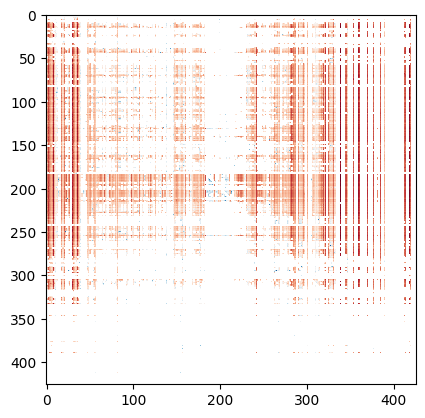

In [12]:
#plot
plt.imshow(np.log(p3),cmap='RdBu')

/tmp/ipykernel_58307/246713654.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(p7),cmap='RdBu')


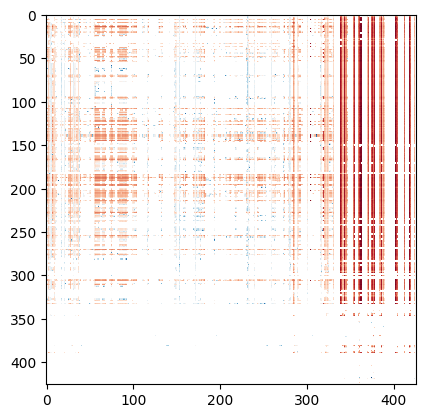

In [13]:
plt.imshow(np.log(p7),cmap='RdBu')

/tmp/ipykernel_58307/3015521285.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(p10),cmap='RdBu')


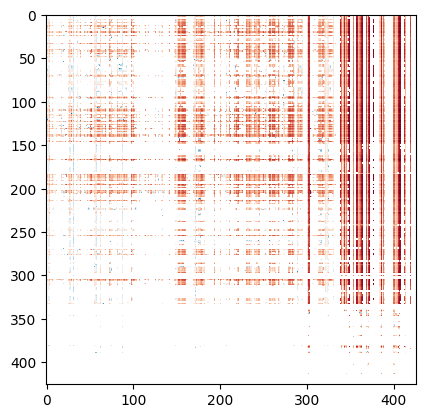

In [14]:
plt.imshow(np.log(p10),cmap='RdBu')

In [22]:
p3[idx].shape
p3[:,idx][idx]


array([[       nan, 0.        , 0.        , ...,        nan,        nan,
        0.        ],
       [0.00917431,        nan, 0.        , ...,        nan,        nan,
        0.        ],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.0008643 , 0.00280636, 0.        , ...,        nan, 0.0078125 ,
        0.        ],
       [0.00110988, 0.00369004, 0.        , ...,        nan,        nan,
        0.        ],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])

/tmp/ipykernel_58307/4095717263.py:2: RuntimeWarning: Mean of empty slice
  idx=np.nanmean(p3,axis=1).argsort()
/tmp/ipykernel_58307/4095717263.py:3: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(p3[:,idx][idx]),cmap='RdBu')


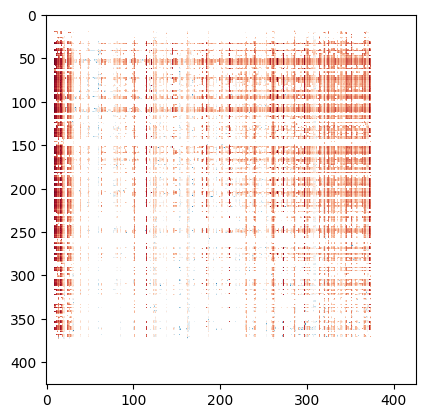

In [25]:
p3[p3==np.nan]=0
idx=np.nanmean(p3,axis=1).argsort()
plt.imshow(np.log(p3[:,idx][idx]),cmap='RdBu')

# Final algorithm that works fine on our test case.  

Consider 5 nodes and 5 consecutive timesteps of node entering the main cluster.


TEST CASE:  
1  
1 2  
1 4 3  
2 5  
1 2 3




In [38]:
# Converting above test case to binary
tc=[[1,0,0,0,0],[1,1,0,0,0],[1,0,1,1,0],[0,1,0,0,1],[1,1,1,0,0]]

# Repeating 1 2 sequence again. (another test case)
tc1= [[1,0,0,0,0],[1,1,0,0,0],[1,1,0,0,0],[1,0,1,1,0],[0,1,0,0,1],[1,1,1,0,0]]

test_mat=np.array(tc,dtype='bool')
nc=test_mat


num=np.zeros((nc.shape[1],nc.shape[1]))
den=np.zeros((nc.shape[1],nc.shape[1]))
for i in range(nc.shape[0]-1):
    
    nc_t=nc[i,:]
    nc_t1=nc[i+1,:]
    M1=np.outer(nc_t,~nc_t)
    M2=np.outer(nc_t1,nc_t1)
    M3=np.outer(nc_t1,~nc_t1)
    M4=np.outer(~nc_t1,nc_t1)
    M5=np.outer(~nc_t1,~nc_t1)
    num+=M1*M2
    den+=M1*(M2+M3+M4+M5)
    
print(f'num: \n {num}')
print(f'den: \n {den}')
prob=num/den
prob=np.nan_to_num(prob)
print(prob)



num: 
 [[0. 1. 1. 1. 0.]
 [1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
den: 
 [[0. 2. 2. 2. 3.]
 [1. 0. 2. 2. 1.]
 [0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 1.]
 [1. 0. 1. 1. 0.]]
[[0.  0.5 0.5 0.5 0. ]
 [1.  0.  0.5 0.  0. ]
 [0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0. ]]


/tmp/ipykernel_168859/4156657144.py:27: RuntimeWarning: invalid value encountered in divide
  prob=num/den


Above results verified with by hand calculations


In [39]:
prob.mean(axis=0)


array([0.2, 0.1, 0.2, 0.1, 0. ])

## Making above algo as a function

In [13]:
def compute_prob_mat(df_nc):
    nc=np.array(df_nc)
    mc = analyse.compute_main_cluster(df_nc)
    nc=nc==mc
    num=np.zeros((nc.shape[1],nc.shape[1]))
    den=np.zeros((nc.shape[1],nc.shape[1]))
    for i in range(nc.shape[0]-1):
        nc_t=nc[i,:]
        nc_t1=nc[i+1,:]
        M1=np.outer(nc_t,~nc_t)
        M2=np.outer(nc_t1,nc_t1)
        M3=np.outer(nc_t1,~nc_t1)
        M4=np.outer(~nc_t1,nc_t1)
        M5=np.outer(~nc_t1,~nc_t1)
        num+=M1*M2
        den+=M1*(M2+M3+M4+M5)
       
    prob=num/den
    return(prob)




In [50]:
c=[]

In [52]:
# let's check if below algo works fine
a= [[1,2],[4,5]]
b=[[3,4],[6,7]]
#c.append(a)
c.append(b)
c

[[[1, 2], [4, 5]], [[3, 4], [6, 7]]]

In [53]:
mc=np.stack(c,axis=0)
mc

array([[[1, 2],
        [4, 5]],

       [[3, 4],
        [6, 7]]])

In [54]:
mc.shape

(2, 2, 2)

In [55]:
mc_avg=np.nanmean(mc,axis=0)
mc_avg

array([[2., 3.],
       [5., 6.]])

#### Applying vector algo to whole node community data of 267 transitions in FN

In [11]:
# this is checked
i=0
f=5000
p_mat_stack=[]
while f < df_ncr.shape[0]:
    # finding node list for given nc data
    l=df_ncr.iloc[i:f,:]
    # calculating probability matrix for above node list
    p_mat = compute_prob_mat(l)
    p_mat=list(p_mat)
    p_mat_stack.append(p_mat)
  
    
    i=f
    f+=5000

p_mat_stack = np.nan_to_num(p_mat_stack)
mat_stack=np.stack(p_mat_stack,axis=0)
mat_avg=np.nanmean(mat_stack,axis=0)



np.save("../../data/raw/prob_avg",mat_avg)

/tmp/ipykernel_227170/864272182.py:18: RuntimeWarning: invalid value encountered in divide
  prob=num/den


In [58]:

mat_stack.shape

(266, 426, 426)

/tmp/ipykernel_227170/2454436825.py:10: RuntimeWarning: divide by zero encountered in log
  axs=ax.imshow(np.log(final_mat),cmap='RdBu')


Text(0, 0.5, 'Puller nodes (arranged as per node communities)')

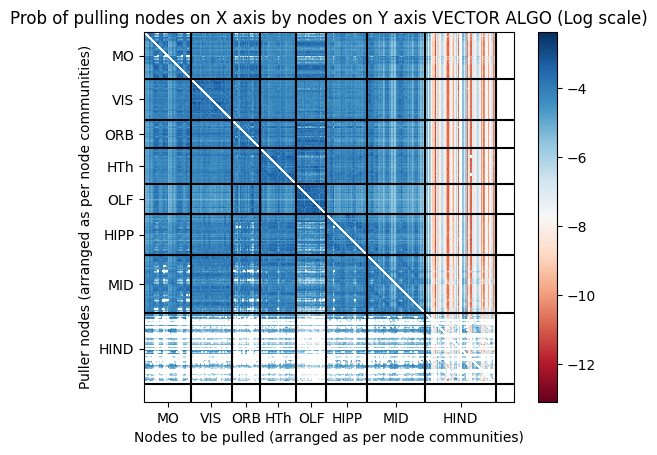

In [200]:
comm=reader.get_communities()
desired_order = comm['des_order']
reordered_mat=mat_avg[desired_order,:]
final_mat=reordered_mat[:,desired_order]
# community divider lines 
com_div = np.cumsum(comm['comm_val'])


fig,ax=plt.subplots()
axs=ax.imshow(np.log(final_mat),cmap='RdBu')
fig.colorbar(axs)
for i in com_div:
    ax.axvline(i,color='k')
    ax.axhline(i,color='k')
ax.set_xticks(com_div-comm['comm_val']/2)
ax.set_xticklabels(comm['name_seq'])

ax.set_yticks(com_div-comm['comm_val']/2)
ax.set_yticklabels(comm['name_seq'])
plt.title('Prob of pulling nodes on X axis by nodes on Y axis VECTOR ALGO (Log scale)')
plt.xlabel('Nodes to be pulled (arranged as per node communities)')
plt.ylabel('Puller nodes (arranged as per node communities)')


In [37]:
_a = np.log(mat_avg)
_a[_a==-np.inf] = np.nan

np.nanmean(_a, axis=1).min()


/tmp/ipykernel_168859/1684295837.py:1: RuntimeWarning: divide by zero encountered in log
  _a = np.log(mat_avg)
/tmp/ipykernel_168859/1684295837.py:4: RuntimeWarning: Mean of empty slice
  np.nanmean(_a, axis=1).min()


nan

In [62]:
mat_avg.max()

0.09240989348217915

(array([ 1.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  3.,
         1.,  1.,  1.,  0.,  2.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,
         1.,  1.,  0.,  1.,  1.,  1.,  1.,  0.,  1.,  1.,  1.,  0.,  1.,
         1.,  1.,  2.,  1.,  0.,  0.,  0.,  1.,  1.,  1.,  2.,  0.,  0.,
         3.,  0.,  2.,  3.,  1.,  1.,  3.,  1.,  0.,  1.,  1.,  2.,  0.,
         1.,  4.,  3.,  4.,  2.,  1.,  3.,  1.,  4.,  5., 10., 10., 12.,
        20., 27., 18., 22., 37., 53., 48., 62., 22.]),
 array([-9.61439116, -9.55988214, -9.50537312, -9.4508641 , -9.39635508,
        -9.34184606, -9.28733704, -9.23282802, -9.178319  , -9.12380998,
        -9.06930096, -9.01479194, -8.96028292, -8.9057739 , -8.85126488,
        -8.79675586, -8.74224684, -8.68773782, -8.6332288 , -8.57871978,
        -8.52421076, -8.46970174, -8.41519272, -8.3606837 , -8.30617468,
        -8.25166566, -8.19715664, -8.14264762, -8.0881386 , -8.033629

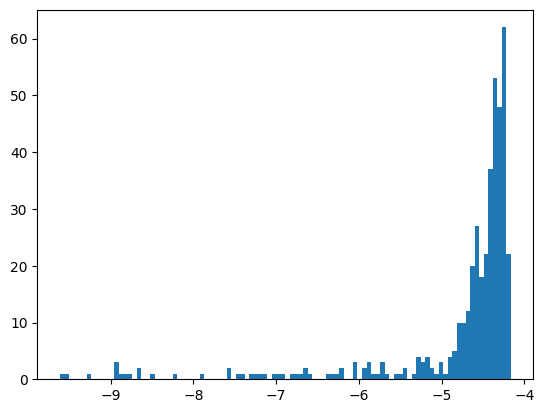

In [43]:
mat_mean=mat_avg.mean(axis=1)
plt.hist(np.log(mat_mean[mat_mean>0]),bins=100)





# plt.imshow(mat_avg,cmap='RdBu')
# plt.colorbar()


In [24]:
mat_avg.min()



0.0

In [114]:
#finding unique probability values and their count
p_val, counts=np.unique(mat_avg,  return_counts=True)
p_sort = np.sort(p_val,axis=None)
p=p_sort[::-1]  #in descending order
p

array([9.24098935e-02, 9.11686152e-02, 8.81685493e-02, ...,
       2.09787863e-06, 2.08971567e-06, 0.00000000e+00])

In [115]:
# looking for node having this prob value

p[0]
np.argwhere(mat_avg==p[0])

array([[108, 321]])

In [116]:
mat_avg[108,321]

0.09240989348217915

In [ ]:
counts[counts>1]

In [121]:
l=np.argwhere(mat_avg==p[0])

In [122]:
l[0]

array([108, 321])

In [111]:
l[0][1]

321

In [107]:
l[0][0]

375

In [128]:
l25=mat_avg[25,:]
l25_sort=np.sort(l25)
l25_sort = l25_sort[::-1]
h=np.argwhere(l25==l25.max())[0][0]
# h[0][0]
h

238

In [94]:
l25_sort.max()

0.054593774066540195

In [13]:
mat_avg[25,238]

0.054593774066540195

In [15]:
mat_avg

array([[0.00000000e+00, 3.96441895e-03, 9.66025699e-03, ...,
        5.89448596e-06, 1.91977079e-04, 2.41202491e-03],
       [2.89184500e-04, 0.00000000e+00, 5.69896479e-03, ...,
        4.31123681e-06, 3.87858812e-04, 8.17094857e-03],
       [3.03301344e-03, 5.94891937e-03, 0.00000000e+00, ...,
        5.31987348e-06, 2.26111110e-04, 3.12637567e-03],
       ...,
       [0.00000000e+00, 2.68528464e-04, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.34962406e-04],
       [8.54408749e-05, 2.40975641e-03, 1.83055876e-03, ...,
        0.00000000e+00, 0.00000000e+00, 5.85680251e-03],
       [7.18606862e-04, 1.52046569e-02, 5.36091411e-03, ...,
        1.16030818e-05, 9.75148529e-04, 0.00000000e+00]])

### load avged matrix from raw data

In [3]:

mat_avg=np.load('../../data/raw/prob_avg.npy')
mat_avg

array([[0.00000000e+00, 3.96441895e-03, 9.66025699e-03, ...,
        5.89448596e-06, 1.91977079e-04, 2.41202491e-03],
       [2.89184500e-04, 0.00000000e+00, 5.69896479e-03, ...,
        4.31123681e-06, 3.87858812e-04, 8.17094857e-03],
       [3.03301344e-03, 5.94891937e-03, 0.00000000e+00, ...,
        5.31987348e-06, 2.26111110e-04, 3.12637567e-03],
       ...,
       [0.00000000e+00, 2.68528464e-04, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.34962406e-04],
       [8.54408749e-05, 2.40975641e-03, 1.83055876e-03, ...,
        0.00000000e+00, 0.00000000e+00, 5.85680251e-03],
       [7.18606862e-04, 1.52046569e-02, 5.36091411e-03, ...,
        1.16030818e-05, 9.75148529e-04, 0.00000000e+00]])

(array([3.5165e+04, 8.5030e+03, 5.6950e+03, 4.8380e+03, 5.4360e+03,
        5.7540e+03, 4.7830e+03, 4.9750e+03, 5.6070e+03, 6.2580e+03,
        6.5670e+03, 6.8620e+03, 6.7900e+03, 6.7770e+03, 6.5040e+03,
        6.1990e+03, 5.8990e+03, 5.3590e+03, 4.9950e+03, 4.4890e+03,
        3.9850e+03, 3.6610e+03, 3.0720e+03, 2.8820e+03, 2.4820e+03,
        2.1730e+03, 2.0220e+03, 1.7780e+03, 1.4980e+03, 1.3450e+03,
        1.1290e+03, 9.9600e+02, 8.9000e+02, 7.6100e+02, 7.1200e+02,
        5.6200e+02, 5.3000e+02, 4.9600e+02, 4.3500e+02, 3.4200e+02,
        2.8400e+02, 2.8300e+02, 2.2200e+02, 2.0600e+02, 1.7200e+02,
        1.4900e+02, 1.2200e+02, 9.7000e+01, 9.8000e+01, 7.6000e+01,
        8.6000e+01, 5.7000e+01, 4.9000e+01, 4.8000e+01, 3.9000e+01,
        4.0000e+01, 3.7000e+01, 2.5000e+01, 2.4000e+01, 2.5000e+01,
        1.5000e+01, 2.4000e+01, 1.5000e+01, 8.0000e+00, 9.0000e+00,
        7.0000e+00, 5.0000e+00, 6.0000e+00, 0.0000e+00, 6.0000e+00,
        4.0000e+00, 2.0000e+00, 1.0000e+00, 3.00

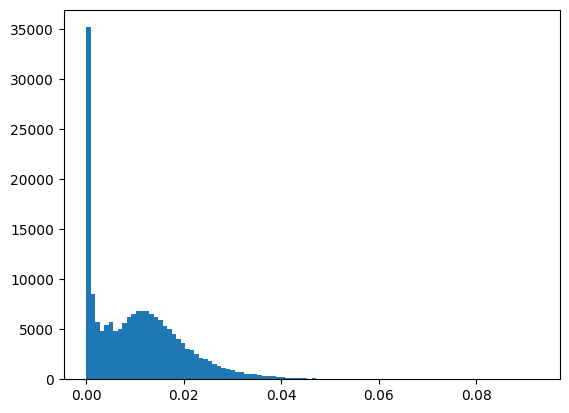

In [5]:
plt.hist(mat_avg.flatten(),bins=100)

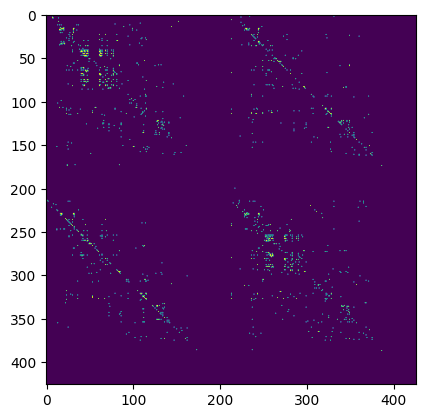

In [9]:
mat_bin=np.zeros(mat_avg.shape)
mat_bin[mat_avg>0.04]=1
plt.imshow(mat_bin)

## Algorithm for node tree  
1. Take first 5 highest probability puller nodes
2. Start from each upto next 20 nodes
3. You need to compare for pulled node row the second maximum probability
   

In [93]:
## Building test for below algorithm 
p_val, counts=np.unique(mat_avg,  return_counts=True)
p_sort = np.sort(p_val,axis=None)
p=p_sort[::-1]  #in descending order

# count for 20 node tree 
count=1

#list to append puller and pulled nodes 
puller_node_list=[]
pulled_node_list=[]


# Taking top 5 prob values
p5=p[range(0,5)]

# finding node pair which has the given probability
mat_cord=np.argwhere(mat_avg==p5[0])

puller_node = mat_cord[0][0]
pulled_node = mat_cord[0][1]
print(f'puller_node {puller_node}')
print(f'pulled_node {pulled_node}')

pulled_node_row=mat_avg[pulled_node,:]
row_sort=np.sort(pulled_node_row)
pn_row_des_sort=row_sort[::-1]

# Finding new puller node
new_puller_node=np.argwhere(pulled_node_row == pn_row_des_sort[1])[0][0]
#new_puller_node=np.argwhere(pulled_node_row == pulled_node_row.max())[0][0]
#pulled_node=new_puller_node

print(f'puller_node {pulled_node}')
print(f'pulled_node {new_puller_node}')


puller_node 108
pulled_node 321
puller_node 321
pulled_node 109


In [48]:
new_puller_node[0][0]

360

In [124]:
pulled_node=40

pulled_node_row=mat_avg[pulled_node,:]
row_sort=np.sort(pulled_node_row)
pn_row_des_sort=row_sort[::-1]

# Finding new puller node
new_puller_node=np.argwhere(pulled_node_row == pn_row_des_sort[0])[0][0]

print(f'puller_node {pulled_node}')
print(f'pulled_node {new_puller_node}')

puller_node 40
pulled_node 253


In [119]:
pulled_node=213

pulled_node_row=mat_avg[pulled_node,:]
row_sort=np.sort(pulled_node_row)
pn_row_des_sort=row_sort[::-1]

# Finding new puller node
new_puller_node=np.argwhere(pulled_node_row == pn_row_des_sort[1])[0][0]

print(f'puller_node {pulled_node}')
print(f'pulled_node {new_puller_node}')

puller_node 213
pulled_node 69


In [61]:
mat_avg[360,238]

0.05803683110866289

In [64]:
mat_avg[360,147]

0.05311914402316836

# Version_1 algorithm to find node tree  

This algorithm does the following:  
1. It picks the max prob node
2. See which node above node picks with max prob
3. Above loop goes on

**Observation:**  
The sequence saturates to some sequence

In [15]:
# Finding unique prob values and sorting them in descending order
p_val, counts=np.unique(mat_avg,  return_counts=True)
p_sort = np.sort(p_val,axis=None)
p=p_sort[::-1]  #in descending order

# count for 20 node tree 
count=1

#list to append nodes in node tree
node_tree=[]
# list to store probability values
prob_values=[]


# Taking top 5 prob values
p5=p[range(0,5)]
#p5=p

# finding node pair which has the given probability
mat_cord=np.argwhere(mat_avg==p5[0])

prn = mat_cord[0][0]
pdn = mat_cord[0][1]

node_tree.append(prn)
node_tree.append(pdn)

prob_values.append(p5[0])
# finding which nodes pulled node pulls with highest probability
dup=[]

while count<=20:
    
    new_puller_node_row=mat_avg[pdn,:]
    row_sort=np.sort(new_puller_node_row)
    pn_row_des_sort=row_sort[::-1]
    
    # Finding new puller node
    pdn=np.argwhere(new_puller_node_row == pn_row_des_sort[0])[0][0]
    pdn_chk=np.argwhere(new_puller_node_row == pn_row_des_sort[0])
    if pdn_chk[0].shape[0] > 1:
        dup.append(pdn[0])
    if pdn == node_tree[-2]:
        pdn=np.argwhere(new_puller_node_row == pn_row_des_sort[1])[0][0]
        prob_values.append(pn_row_des_sort[1])
    else:
        prob_values.append(pn_row_des_sort[0])
        

    
    #new_puller_node=np.argwhere(pulled_node_row == pulled_node_row.max())[0][0]
    
    node_tree.append(pdn)
    
    count+=1


print(f'{node_tree}')
print(f'{prob_values}')

[108, 321, 109, 243, 255, 26, 239, 0, 213, 69, 62, 40, 253, 283, 70, 62, 40, 253, 283, 70, 62, 40]
[0.09240989348217915, 0.06431697200631858, 0.053869556951279214, 0.05069567976634695, 0.048403116868902626, 0.052125079200955035, 0.042434498241499134, 0.05713371479720318, 0.03442879284255111, 0.055858024493725636, 0.047039118130178595, 0.047094735971998675, 0.03851915738293228, 0.04115339866171712, 0.053093346633516336, 0.047039118130178595, 0.047094735971998675, 0.03851915738293228, 0.04115339866171712, 0.053093346633516336, 0.047039118130178595]


# Version_2 Algorithm Node tree  
- Take top 10% of highest probability nodes
- Then take again top 10%

In [55]:
mat_avg.max()

0.09240989348217915

In [56]:
np.argwhere(mat_avg==mat_avg.max())[0]

array([108, 321])

In [57]:
# criteria for top 10% high probability nodes
new_prob_criteria = mat_avg.max() - 0.1*(mat_avg.max())
new_prob_criteria

0.08316890413396123

In [59]:
top_10_per_nodes = np.argwhere(mat_avg > new_prob_criteria)
top_10_per_nodes


array([[ 36, 249],
       [108, 321],
       [375, 162]])

#### Question is should I take all nodes from 1 hemisphere or not?

Let's try and see  

Taking nodes 36,108,162  


In [9]:
def find_top_10_in_a_row(node):  
    a=list(mat_avg[node,:]) # taking all probabilities in that row
    a.sort() # sorting row by default in ascending order
    a_des=a[::-1] # reversing row probabilities in descending order


    # finding top 10% nodes which are pulled by this node 

    prob_threshold = a_des[0]-0.1*a_des[0] # considering nodes which are pulled by prob greater than this prob value
    a=np.array(a)
    top_10_nodes=np.argwhere(a>prob_threshold)

    return top_10_nodes
    

# a=list(mat_avg[249,:])
# a.sort()
# a_des=a[::-1]
# new_orb_crit = a_des[0] - 0.1*a_des[0]
    
# new_orb_crit
# a=np.array(a)
# top_10_per_nodes_a = np.argwhere(a>new_orb_crit)
# top_10_per_nodes_a[0]

In [17]:
a=find_top_10_in_a_row(36)
a
b=find_top_10_in_a_row(425)
b
c=find_top_10_in_a_row(424)
c


array([[425]])

In [20]:
a=find_top_10_in_a_row(162)[0]
a
# b=find_top_10_in_a_row(425)
# b
# c=find_top_10_in_a_row(424)
# c

array([425])

In [ ]:
a=find_top_10_in_a_row(108)[0]
a
b=find_top_10_in_a_row(425)
b
# c=find_top_10_in_a_row(424)
# c

In [64]:
a[425]

0.05894384686340849

In [66]:
a=list(mat_avg[425,:])
a.sort()
a_des=a[::-1]
new_orb_crit = a_des[0] - 0.1*a_des[0]
new_orb_crit
a=np.array(a)
top_10_per_nodes_a = np.argwhere(a>new_orb_crit)
top_10_per_nodes_a[0]


array([424])

In [31]:
np.argwhere(mat_avg>updated_crit)

array([[ 36, 249],
       [ 94, 108],
       [108, 321],
       [238,  25],
       [277,  64],
       [307,  94],
       [349, 136],
       [375, 162]])

Text(0.5, 1.0, 'Plot of probability values in a matrix')

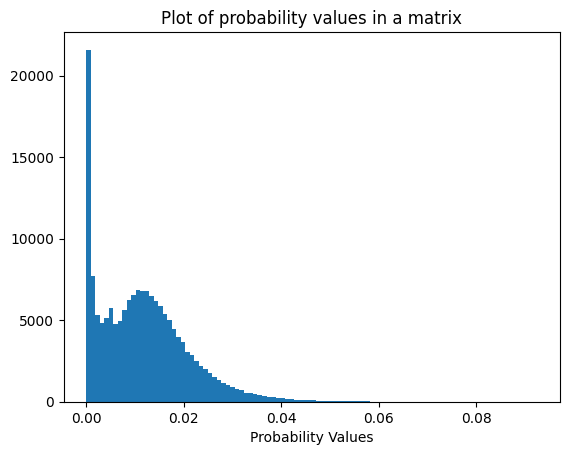

In [25]:
plt.hist(p,bins=100)
plt.xlabel('Probability Values')
plt.title('Plot of probability values in a matrix')

In [22]:
# Finding unique prob values and sorting them in descending order
p_val, counts=np.unique(mat_avg,  return_counts=True)
p_sort = np.sort(p_val,axis=None)
p=p_sort[::-1]  #in descending order


[108, 321, 109, 243, 255, 26, 239, 0, 213, 69, 62, 40, 253, 283, 70, 62, 40, 253, 283, 70, 62, 40, 253, 283, 70, 62, 40, 253, 283, 70, 62, 40]
[0.09240989348217915, 0.06431697200631858, 0.053869556951279214, 0.05069567976634695, 0.048403116868902626, 0.052125079200955035, 0.042434498241499134, 0.05713371479720318, 0.03442879284255111, 0.055858024493725636, 0.047039118130178595, 0.047094735971998675, 0.03851915738293228, 0.04115339866171712, 0.053093346633516336, 0.047039118130178595, 0.047094735971998675, 0.03851915738293228, 0.04115339866171712, 0.053093346633516336, 0.047039118130178595, 0.047094735971998675, 0.03851915738293228, 0.04115339866171712, 0.053093346633516336, 0.047039118130178595, 0.047094735971998675, 0.03851915738293228, 0.04115339866171712, 0.053093346633516336, 0.047039118130178595]

### Brain region

In [13]:
a=reader.data_read_csv('connectivity_matrix/contralateral_original_conn_filtered.csv')

b=reader.data_read_csv('connectivity_matrix/ipsilateral_original_conn_filtered.csv')

ipsi_node_region = b.iloc[0,:]
contra_node_region = a.iloc[0,:]
no_trans_nodes = [62, 40, 253, 283, 70]

for i in no_trans_nodes:
    if i<213:
        print(f'For node {i}, the brain region is {contra_node_region[i]}')
    else:
        j=i-213
        print(f'For node {i}, the brain region is {ipsi_node_region[j]}')

For node 62, the brain region is EPv
For node 40, the brain region is AON
For node 253, the brain region is AON
For node 283, the brain region is OT
For node 70, the brain region is OT


For node 62, the brain region is EPv (Piriform cortex)  
For node 40, the brain region is AON  (Olfactory cortex)  
For node 253, the brain region is AON  (Olfactory cortex)  
For node 283, the brain region is OT (Olfactory cortex)  
For node 70, the brain region is OT  (Olfactory cortex)

### On betweenness curve

In [4]:
b=reader.data_read_pkl('raw/betw.pkl')


In [ ]:
b


In [5]:
#storing betweenness centrality values
val=[]
for i in b:
    val.append(b[i])




In [6]:
node=list(b.keys())

keys=node
values=list(range(0,426))
node_map=dict(zip(keys,values))

Text(0, 0.5, 'Betweenness centrality')

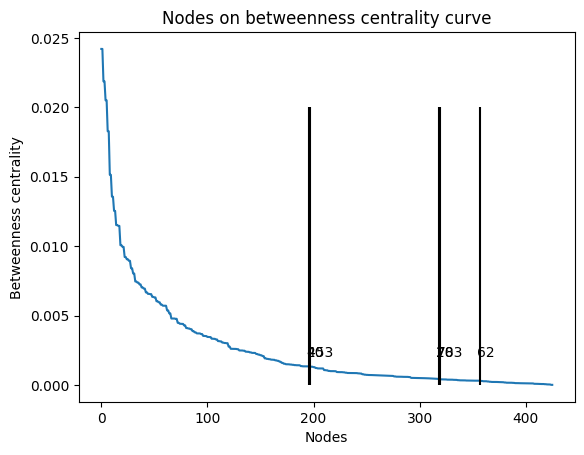

In [11]:
fig,ax = plt.subplots()
ax.plot(val)

keys=node
values=list(range(0,426))
node_map=dict(zip(keys,values))


node_list=[62,40,253,283,70]

for i in node_list:
    ax.vlines(node_map[i],0,0.02,colors='k')
    ax.text(node_map[i]-3,0.002,i)
    
ax.set_title('Nodes on betweenness centrality curve')
ax.set_xlabel('Nodes')
ax.set_ylabel('Betweenness centrality')



#### NOTE:  
40,62,253,283 is same node on both hemisphere but why not in above case?

### Nodes on time spent and degree plot

In [24]:
df_nc=reader.data_read_bz2('raw/FN/nc_200.bz2')

df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')


# here G is the undirected graph
G = nx.from_numpy_array(l.WHOLE_BRAIN_CONN)

In [25]:
df_r=df_nc.reset_index(drop=True)

In [26]:
i=0
f=5000
time_list=[]
node_list=[]
while f < df_r.shape[0]:
    l=analyse.compute_time_spent_mc(df_r.iloc[i:f,:])
    node_list.append(l)
    i=f
    f+=5000

df_time_spent = pd.DataFrame(node_list)
df_time_spent.shape

(127, 426)

In [27]:
# calculate median of every column
MTS = df_time_spent.median()
med_time_spent = list(MTS)
keys=list(range(0,426))
mts_dict=dict(zip(keys,med_time_spent))
mts_sorted =dict(sorted(mts_dict.items(), key=lambda item: item[1]))

In [28]:
degree = nx.degree_centrality(G)
degree_val =list(degree.values())

In [29]:
deg_sort=dict(sorted(degree.items(), key=lambda item: item[1]))

Text(0.5, 1.0, 'Scatter plot of Median Time Spent vs Degree')

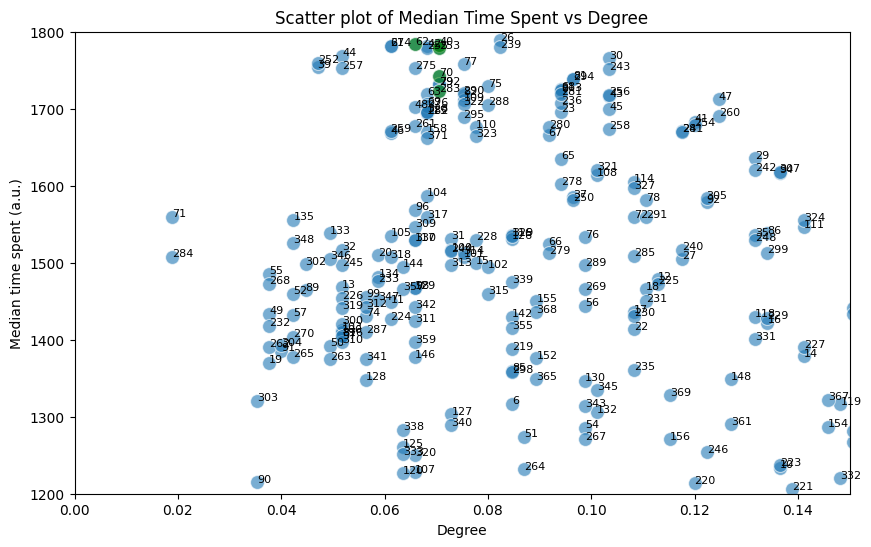

In [37]:
plt.figure(figsize=(10, 6))
ax=sns.scatterplot(x=degree_val, y=med_time_spent, s=100, alpha=0.6, edgecolor='w')

for i, txt in enumerate(keys):
    ax.annotate(txt, (degree_val[i], med_time_spent[i]), fontsize=8)


node_list=[62,40,253,283,70]
#getting degree and median time spent values for node list
tdeg=[]
tmts=[]
for i in node_list:
    tdeg.append(degree_val[i])
    tmts.append(med_time_spent[i])

ax=sns.scatterplot(x=tdeg,y=tmts,s=100,alpha=0.6,color='green')


# defining function to plot nodes wrt their color

def node_color(color_nodes,color,degree_val,med_time_spent):
    plt.figure(figsize=(10, 6))
    ax=sns.scatterplot(x=degree_val, y=med_time_spent, s=100, alpha=0.6, edgecolor='w')
    
    for i, txt in enumerate(keys):
        ax.annotate(txt, (degree_val[i], med_time_spent[i]), fontsize=8)
    tdeg=[]
    tmts=[]
    for i in color_nodes:
        tdeg.append(degree_val[i])
        tmts.append(med_time_spent[i])
    
    ax=sns.scatterplot(x=tdeg,y=tmts,s=100,alpha=0.6,color='green')
    

plt.xlim(0, 0.15)  # Adjust the range as needed
plt.ylim(1200,1800)  
plt.xlabel('Degree')
plt.ylabel('Median time spent (a.u.)')
plt.title('Scatter plot of Median Time Spent vs Degree')


## Defining function to plot nodes with color

In [40]:
# defining function to plot nodes wrt their color

def node_color(color_nodes,color,degree_val,med_time_spent):
    plt.figure(figsize=(10, 6))
    ax=sns.scatterplot(x=degree_val, y=med_time_spent, s=100, alpha=0.6, edgecolor='w')
    
    for i, txt in enumerate(keys):
        ax.annotate(txt, (degree_val[i], med_time_spent[i]), fontsize=8)
    tdeg=[]
    tmts=[]
    for i in color_nodes:
        tdeg.append(degree_val[i])
        tmts.append(med_time_spent[i])
    
    ax=sns.scatterplot(x=tdeg,y=tmts,s=100,alpha=0.6,color='green')

    plt.xlim(0, 0.15)  # Adjust the range as needed
    plt.ylim(1200,1800)  
    plt.xlabel('Degree')
    plt.ylabel('Median time spent (a.u.)')
    plt.title('Scatter plot of Median Time Spent vs Degree')

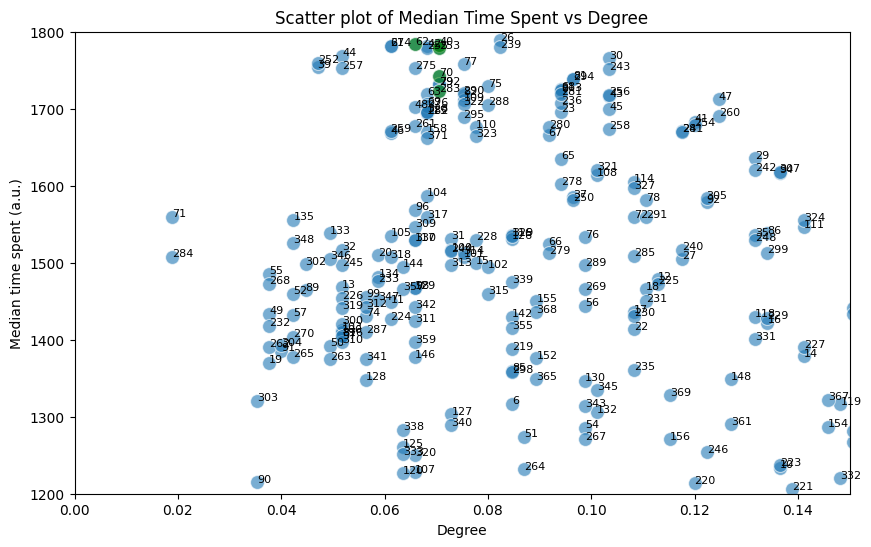

In [41]:
node_color([62,40,70,253,283],'k',degree_val,med_time_spent)

In [195]:
dup

[]

In [183]:
new_puller_node_row=mat_avg[62,:]
row_sort=np.sort(new_puller_node_row)
pn_row_des_sort=row_sort[::-1]
pdn=np.argwhere(new_puller_node_row == pn_row_des_sort[0])
pdn

array([[40]])

In [190]:
a=np.array([[30,40]])
a[0].shape[0]

2

In [180]:
node_tree==62

False

In [181]:
node_tree.index(62)

10

In [179]:
prob_values[9]

0.055858024493725636

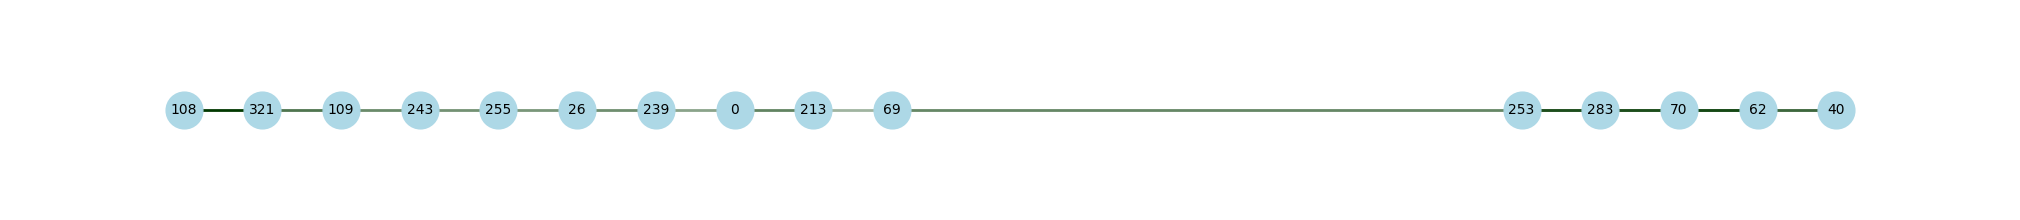

In [176]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph
G = nx.Graph()

for i,val in enumerate(node_tree): 
    G.add_node(val,pos=(1*i,0))


for r,v in enumerate(prob_values):
    G.add_edge(node_tree[r],node_tree[r+1],weight=v)
# Add nodes
# G.add_node(1, pos=(0, 1))
# G.add_node(2, pos=(1, 2))
# G.add_node(3, pos=(2, 1))
# G.add_node(4, pos=(1, 0))
# G.add_node(5, pos=(3, 2))
# G.add_node(6, pos=(4, 1))

# # Add edges with weights (strength)
# G.add_edge(1, 2, weight=0.5)
# G.add_edge(2, 3, weight=0.8)
# G.add_edge(3, 4, weight=0.3)
# G.add_edge(2, 5, weight=1.0)
# G.add_edge(5, 6, weight=0.6)

# Get positions
pos = nx.get_node_attributes(G, 'pos')

# Extract edge weights for styling
edges = G.edges(data=True)
weights = [d['weight'] for (u, v, d) in edges]

# Normalize weights for edge darkness
max_weight = max(weights)
normalized_weights = [w / max_weight for w in weights]
colors = [(255, 200, 0, alpha) for alpha in normalized_weights]  # RGBA for edge color (0,0,0 = black)

# Draw the graph
plt.figure(figsize=(20,2))
nx.draw(
    G, pos, with_labels=True, 
    node_size=700, node_color='lightblue', 
    font_size=10, font_color='black', 
    edge_color=colors, width=2.0
)

plt.show()

In [177]:
mat_avg[213,69]

0.03442879284255111

In [66]:
counts

array([9452,    1,    1, ...,    1,    1,    1])

In [69]:
len(p_val)

166334

In [70]:
426*426

181476

In [72]:
len(counts)

166334

## Writing function to see which all probability values occur and for what node pairs

In [15]:
#defining function to peek inside probablility mprob_matrix
def peek_prob(p):
    l=np.unique(p)
    ls=np.sort(l,axis=None)
    # calculating prob values 
    # p_val=ls[::-1][1:10]
    p_val=ls[::-1]

    ind_max=np.argwhere(p==p_val[0])
    i1=list(ind_max)
    ind_2max=np.argwhere(p==p_val[1])
    i2=list(ind_2max)
    ind_3max=np.argwhere(p==p_val[2])
    i3=list(ind_3max)
    ind_4max=np.argwhere(p==p_val[3])
    i4=list(ind_4max)
    ind_5max=np.argwhere(p==p_val[4])
    i5=list(ind_5max)
    ind_6max=np.argwhere(p==p_val[5])
    i6=list(ind_6max)

    ind_7max=np.argwhere(p==p_val[6])
    i7=list(ind_7max)
    ind_8max=np.argwhere(p==p_val[7])
    i8=list(ind_8max)
    ind_9max=np.argwhere(p==p_val[8])
    i9=list(ind_9max)

    print(f'The length of array for prob {p_val[0]} is {len(ind_max)}')
    print(f'The length of array for prob {p_val[1]} is {len(ind_2max)}')
    print(f'The length  of array for prob {p_val[2]} is {len(ind_3max)}')
    print(f'The length of array for prob {p_val[3]} is {len(ind_4max)}')
    print(f'The length of array for prob {p_val[4]} is {len(ind_5max)}')
    print(f'The length of array for prob {p_val[5]} is {len(ind_6max)}')
    print(f'The length  of array for prob {p_val[6]} is {len(ind_7max)}')
    print(f'The length of array for prob {p_val[7]} is {len(ind_8max)}')
    print(f'The length of array for prob {p_val[8]} is {len(ind_9max)}')
    
    
    values=[i1,i2,i3,i4]
    keys=['p1','p2','p3','p4']
    node_pair_dict = dict(zip(keys,values))
    return p_val #node_pair_dict




#### Checking above function for TEST CASE

In [17]:

l=
peek_prob(mat_avg)




The length of array for prob 0.09413831190390587 is 1
The length of array for prob 0.09116298957881278 is 1
The length  of array for prob 0.0889126405845354 is 1
The length of array for prob 0.08806859792979198 is 1
The length of array for prob 0.08748681928467261 is 1
The length of array for prob 0.08627154933074936 is 1
The length  of array for prob 0.08475593393472328 is 1
The length of array for prob 0.08435084458918869 is 1
The length of array for prob 0.08298496725512393 is 1


peek_prob function works fine on test case.  
**To read:**  
p1 is probability 1. The probability of node 0 pulling node 1 is 1.  
Similarly, the probability of node 0 pulling node 1,2 and 3 is 0.5

In [1]:
l=peek_prob(maat_avg)


NameError: name 'peek_prob' is not defined

# Looking in probability avg matrix

In [43]:
l=peek_prob(mat_avg)

The length of array for prob 1.0 is 23
The length of array for prob 0.6666666666666666 is 1
The length  of array for prob 0.6 is 1
The length of array for prob 0.5625 is 1


In [57]:
type(l['p1'])
data=l['p1']
#flattened_list = [num for arr in data for num in arr]
flattened_list=[arr[0] for arr in data]
flattened_list=list(set(flattened_list))
print(flattened_list)


[1, 194, 196, 391, 137, 169, 171, 362, 393, 210, 180, 149, 150, 406, 184, 409]


In [58]:
type(l['p3'])
data=l['p3']
#flattened_list = [num for arr in data for num in arr]
flattened_list=[arr[0] for arr in data]
flattened_list=list(set(flattened_list))
print(flattened_list)

[180]


In [29]:
l


,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
630000,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
630001,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
630002,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
630003,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
630004,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634995,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
634996,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
634997,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
634998,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1]:
l



NameError: name 'l' is not defined

In [5]:
mat = np.load("../../data/raw/prob_avg.npy")



In [7]:
l=peek_prob(mat)


The length of array for prob 1.0 is 23
The length of array for prob 0.6666666666666666 is 1
The length  of array for prob 0.6 is 1
The length of array for prob 0.5625 is 1


In [13]:
pull_nodes=[]
for i in l['p1']:
 
    pull_nodes.append(i[1])





In [14]:
pull_nodes




[213,
 61,
 307,
 307,
 322,
 375,
 0,
 239,
 346,
 313,
 51,
 229,
 231,
 244,
 257,
 61,
 292,
 146,
 142,
 30,
 77,
 288,
 129]